# Decodability vs LDA 1 - session-averaged summary
Decodability averaged across regions -> one value per session, then correlated with LDA 1.
Block decoding (with/without pseudosession correction) and stimulus decoding (with/without pre-stimulus-control correction). All at **k = 10 PCA components**.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
N_EVAL = 10   # PCA components used for decodability

In [16]:
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

# --- BLOCK (pre-stim, trial-matched + pseudosession), values already at k=10 ---
blk = pd.read_parquet(prefix + 'neural/decoding/decoding_block_pseudo_persession.parquet')
blk_s = blk.groupby('session').agg(block_real=('real', 'mean'),
                                    block_corr=('corrected', 'mean')).reset_index()

# --- STIMULUS (evoked [0,0.1] & control [-0.1,0]), take k=10 ---
stim = pd.read_parquet(prefix + 'neural/decoding_stim_window_persession.parquet')
s10 = stim[stim['n_components'] == N_EVAL]
piv = s10.pivot_table(index=['session', 'region'], columns='window', values='accuracy').dropna(subset=['evoked','control'])
piv['delta'] = piv['evoked'] - piv['control']
stim_s = piv.groupby('session').agg(stim_evoked=('evoked', 'mean'),
                                     stim_sensory=('delta', 'mean')).reset_index()

summ = blk_s.merge(stim_s, on='session', how='outer').merge(lda[['session', 'lda_1']], on='session').dropna(subset=['lda_1'])
print(f"sessions: block={blk_s.shape[0]}, stim={stim_s.shape[0]}, merged with LDA={len(summ)}")

sessions: block=238, stim=238, merged with LDA=238


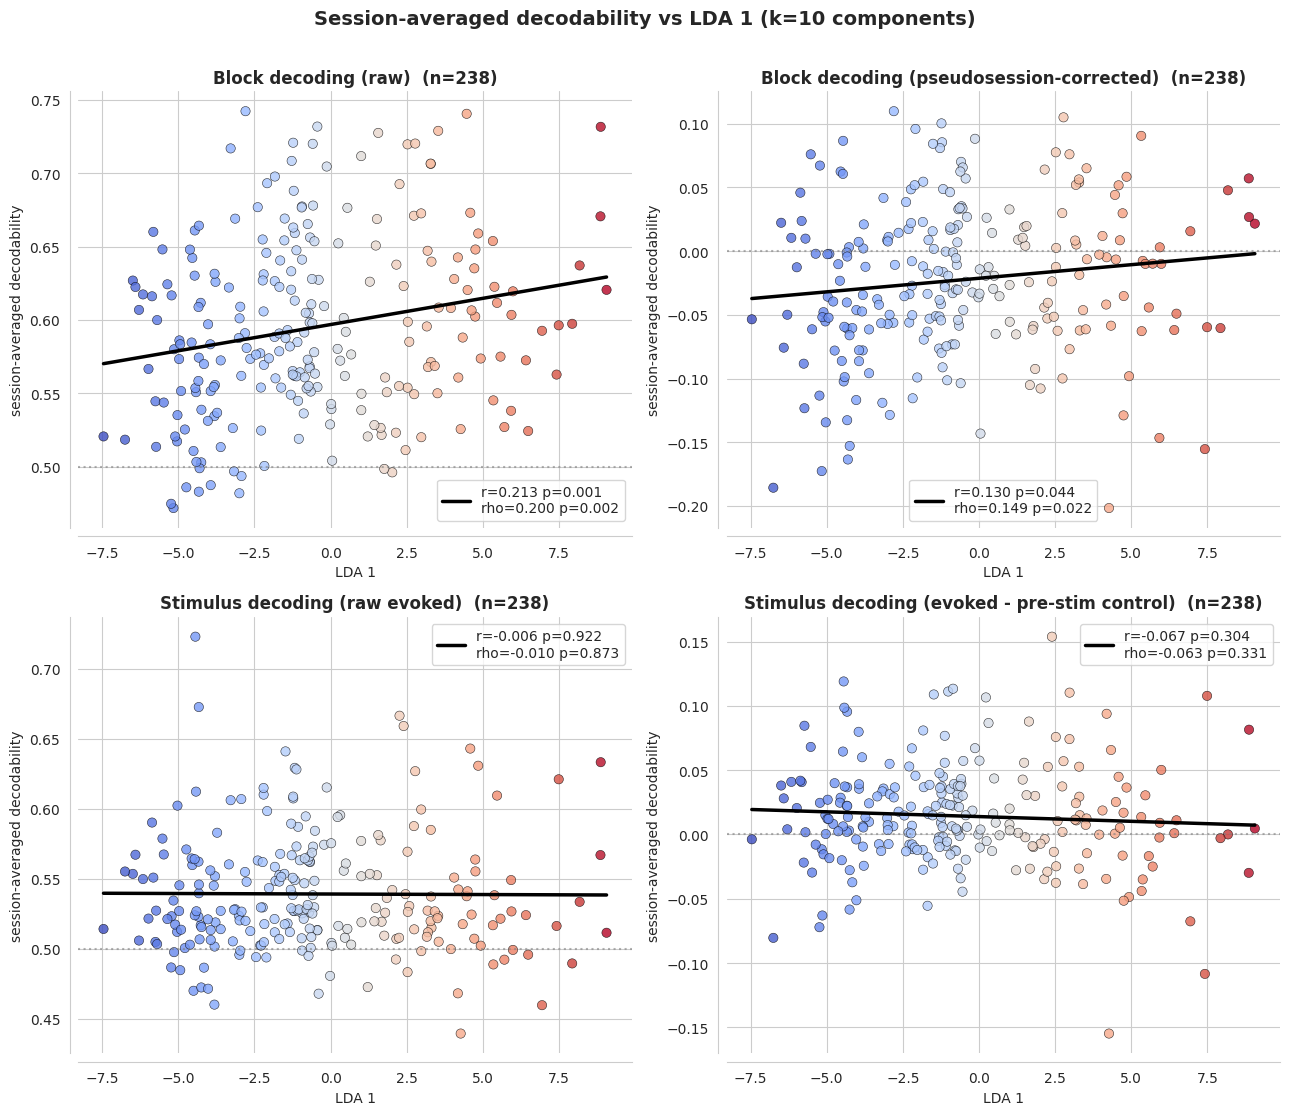

Session-level correlations (decodability averaged across regions):
  Block decoding (raw)                          n=238: pearson r=+0.213 p=0.001 | spearman rho=+0.200 p=0.002
  Block decoding (pseudosession-corrected)      n=238: pearson r=+0.130 p=0.044 | spearman rho=+0.149 p=0.022
  Stimulus decoding (raw evoked)                n=238: pearson r=-0.006 p=0.922 | spearman rho=-0.010 p=0.873
  Stimulus decoding (evoked - pre-stim control) n=238: pearson r=-0.067 p=0.304 | spearman rho=-0.063 p=0.331


In [17]:
panels = [
    ('block_real',   'Block decoding (raw)',                 0.5),
    ('block_corr',   'Block decoding (pseudosession-corrected)', 0.0),
    ('stim_evoked',  'Stimulus decoding (raw evoked)',        0.5),
    ('stim_sensory', 'Stimulus decoding (evoked - pre-stim control)', 0.0),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (col, title, ref) in zip(axes.ravel(), panels):
    g = summ.dropna(subset=[col])
    x, y = g['lda_1'].values, g[col].values
    r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
    ax.scatter(x, y, c=x, cmap='coolwarm', s=45, alpha=0.8, edgecolors='black', linewidth=0.4)
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5,
            label=f'r={r:.3f} p={pv:.3f}\nrho={rho:.3f} p={pvv:.3f}')
    ax.axhline(ref, color='gray', ls=':', alpha=0.6)
    ax.set_xlabel('LDA 1'); ax.set_ylabel('session-averaged decodability')
    ax.set_title(f'{title}  (n={len(g)})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best'); sns.despine(ax=ax, offset=6)
fig.suptitle(f'Session-averaged decodability vs LDA 1 (k={N_EVAL} components)', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("Session-level correlations (decodability averaged across regions):")
for col, title, _ in panels:
    g = summ.dropna(subset=[col]); r, pv = pearsonr(g['lda_1'], g[col]); rho, pvv = spearmanr(g['lda_1'], g[col])
    print(f"  {title:45s} n={len(g):3d}: pearson r={r:+.3f} p={pv:.3f} | spearman rho={rho:+.3f} p={pvv:.3f}")